## Gestion des imports

In [1]:
import matplotlib.image as mpimg
from matplotlib import pyplot as plt
import seaborn as sns
import cv2
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report, f1_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, Activation, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import SGD, Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator


## Création de fonction pour visualiser les résultats

In [2]:
#Création d'une fonction pour visualiser l'apprentissage d'un modèle
def plot_training_history(history):
    train_loss = history.history['loss']
    val_loss = history.history['val_loss']
    train_accuracy = history.history['accuracy']
    val_accuracy = history.history['val_accuracy']

    # Créer un graphique pour la perte
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.plot(train_loss, label='Perte d\'entraînement', color='blue')
    plt.plot(val_loss, label='Perte de validation', color='red')
    plt.legend()
    plt.xlabel('Époque')
    plt.title('Perte au fil des époques')

    # Créer un graphique pour l'accuracy
    plt.subplot(1, 2, 2)
    plt.plot(train_accuracy, label='Accuracy d\'entraînement', color='blue')
    plt.plot(val_accuracy, label='Accuracy de validation', color='red')
    plt.legend()
    plt.xlabel('Époque')
    plt.title('Accuracy au fil des époques')

    # Afficher les graphiques
    plt.tight_layout()
    plt.show()

# Fonction pour afficher la matrice de confusion
def plot_confusion_matrix(y_true, y_pred):
    classe = [ "Jungle", "Plage", "Monuments", "Bus", "Dinosaures", "Elephants", "Fleurs", "Chevaux", "Montagne" , "Plats"]
    classe.sort()
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classe, yticklabels=classe)
    plt.xlabel('Prédictions')
    plt.ylabel('Vraies étiquettes')
    plt.title('Matrice de Confusion')
    plt.show()


## Importation, normalisation des images 
## Création des labels associés aux images, séparation du jeu de données en 2

In [3]:
#Création d'une liste avec l'ensemble des noms d'images
img_name = list()
for i in range(0,1000):
    img_name.append(str(i)+".jpg")
    
#Importation et formattage des images    
images = []
target_shape = (256, 256) 
for img in img_name:
    img = mpimg.imread('./Wang/' + img)
    img = cv2.resize(img, target_shape)
    images.append(img)

images = np.array(images)

# Normaliser les données en divisant par 255
images_normalized = images / 255.0
# Création des labels associés aux images
classe = [ "Jungle", "Plage", "Monuments", "Bus", "Dinosaures", "Elephants", "Fleurs", "Chevaux", "Montagne" , "Plats"]
label = []
for i in range(10):
    a = 0
    while a <100:
        label.append(classe[i])
        a+=1

# Convertir les étiquettes en encodage numérique
label_encoder = LabelEncoder()
label_encoded = label_encoder.fit_transform(label)
#Séparation du jeu de données en train et test
X_train, X_test, y_train, y_test = train_test_split(images_normalized, label_encoded, test_size=0.3, random_state=42)

# Création du premier modèle prédictif

In [20]:
# Créer un modèle CNN simple
model = Sequential()

model.add(Conv2D(32, (3, 3), input_shape=(256, 256, 3)))
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Flatten())
model.add(Dense(10, activation='softmax'))

# Compiler le modèle
model.compile(loss='sparse_categorical_crossentropy', optimizer=SGD(learning_rate=0.01), metrics=['accuracy'])

# Entraîner le modèle
history = model.fit(X_train, y_train, epochs=50, batch_size=50, validation_split=0.2)

# Évaluer le modèle sur l'ensemble de test
accuracy = model.evaluate(X_test, y_test)
print("Précision sur l'ensemble de test :", accuracy[1])


Epoch 1/50
12/12 [==============================] - 13s 1000ms/step - loss: 4.0903 - accuracy: 0.2054 - val_loss: 2.7209 - val_accuracy: 0.1429
Epoch 2/50
12/12 [==============================] - 11s 937ms/step - loss: 2.1399 - accuracy: 0.2357 - val_loss: 2.1389 - val_accuracy: 0.1857
Epoch 3/50
12/12 [==============================] - 10s 852ms/step - loss: 1.8077 - accuracy: 0.3821 - val_loss: 1.6881 - val_accuracy: 0.3786
Epoch 4/50
12/12 [==============================] - 10s 820ms/step - loss: 1.7561 - accuracy: 0.4054 - val_loss: 1.8058 - val_accuracy: 0.4357
Epoch 5/50
12/12 [==============================] - 10s 821ms/step - loss: 1.3649 - accuracy: 0.5589 - val_loss: 1.3767 - val_accuracy: 0.5286
Epoch 6/50
12/12 [==============================] - 10s 794ms/step - loss: 1.0389 - accuracy: 0.6679 - val_loss: 1.6997 - val_accuracy: 0.4929
Epoch 7/50
12/12 [==============================] - 10s 814ms/step - loss: 1.0037 - accuracy: 0.6696 - val_loss: 1.3733 - val_accuracy: 0.514

In [21]:
y_predict = model.predict(X_test)

10/10 [==============================] - 9s 644ms/step


Visualisation des courbes d'entraînement

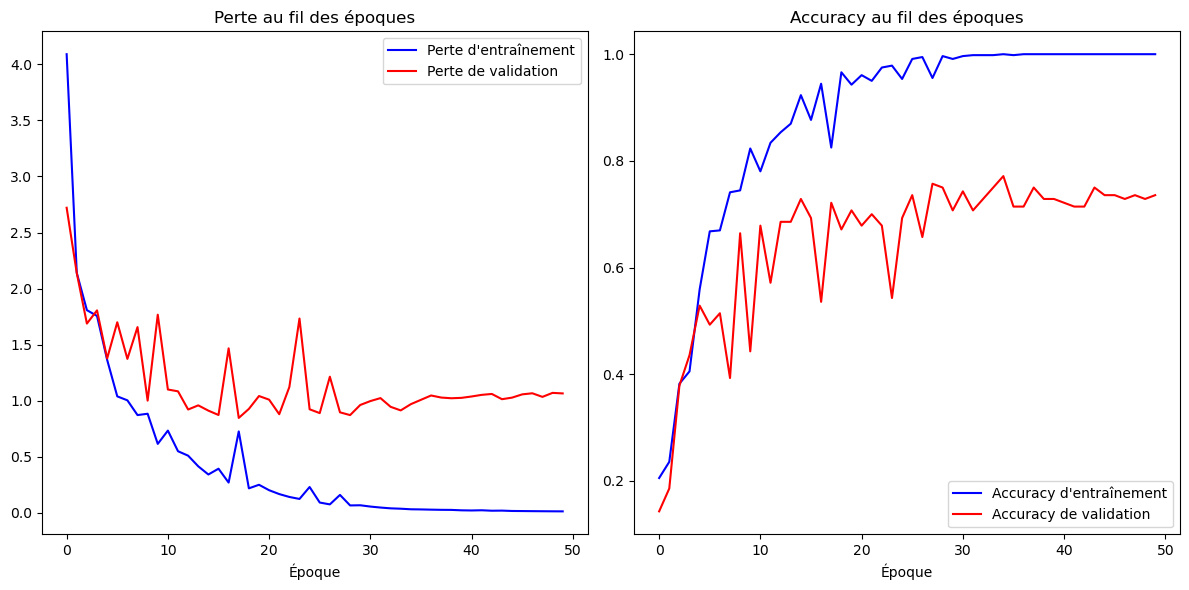

In [26]:
plot_training_history(history)

# Visualisation de la matrice de confusion

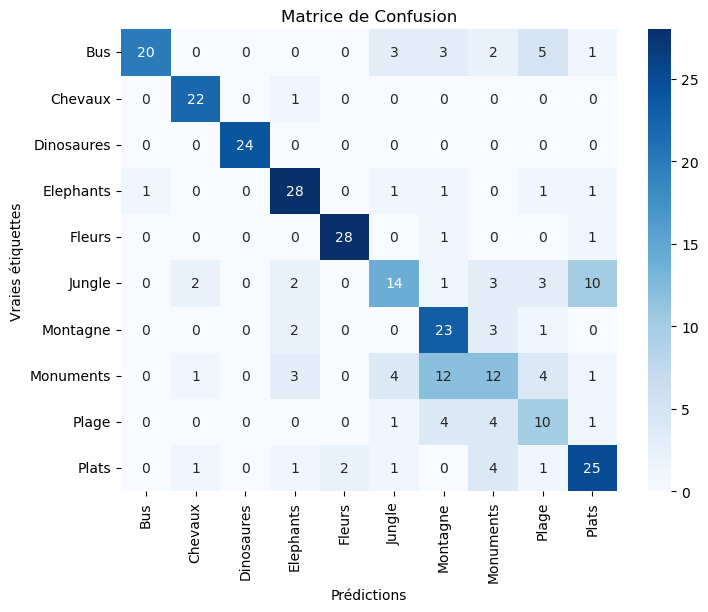

In [54]:
plot_confusion_matrix(y_test, np.argmax(y_predict, axis=1))

# Rapport de classification

In [53]:
print(classification_report(label_encoder.inverse_transform(y_test), label_encoder.inverse_transform(np.argmax(y_predict, axis=1))))

              precision    recall  f1-score   support

         Bus       0.95      0.59      0.73        34
     Chevaux       0.85      0.96      0.90        23
  Dinosaures       1.00      1.00      1.00        24
   Elephants       0.76      0.85      0.80        33
      Fleurs       0.93      0.93      0.93        30
      Jungle       0.58      0.40      0.47        35
    Montagne       0.51      0.79      0.62        29
   Monuments       0.43      0.32      0.37        37
       Plage       0.40      0.50      0.44        20
       Plats       0.62      0.71      0.67        35

    accuracy                           0.69       300
   macro avg       0.70      0.71      0.69       300
weighted avg       0.70      0.69      0.68       300



# Test du même modèle avec arrêt anticipé

In [58]:
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
model = Sequential()

model.add(Conv2D(32, (3, 3), input_shape=(256, 256, 3)))
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Flatten())
model.add(Dense(10, activation='softmax'))

# Compiler le modèle
model.compile(loss='sparse_categorical_crossentropy', optimizer=SGD(learning_rate=0.01), metrics=['accuracy'])

# Entraîner le modèle
history = model.fit(X_train, y_train, epochs=50, batch_size=50, validation_split=0.2, callbacks=[early_stopping])

# Évaluer le modèle sur l'ensemble de test
accuracy = model.evaluate(X_test, y_test)
print("Précision sur l'ensemble de test :", accuracy[1])



Epoch 1/50
12/12 [==============================] - 12s 893ms/step - loss: 3.8638 - accuracy: 0.2196 - val_loss: 2.0381 - val_accuracy: 0.3500
Epoch 2/50
12/12 [==============================] - 10s 822ms/step - loss: 1.8484 - accuracy: 0.3857 - val_loss: 2.7864 - val_accuracy: 0.1286
Epoch 3/50
12/12 [==============================] - 10s 812ms/step - loss: 1.5695 - accuracy: 0.5036 - val_loss: 2.1565 - val_accuracy: 0.3000
Epoch 4/50
12/12 [==============================] - 10s 845ms/step - loss: 1.3998 - accuracy: 0.5464 - val_loss: 2.2986 - val_accuracy: 0.2286
Epoch 5/50
12/12 [==============================] - 10s 819ms/step - loss: 2.2979 - accuracy: 0.3625 - val_loss: 1.8604 - val_accuracy: 0.2857
Epoch 6/50
12/12 [==============================] - 10s 804ms/step - loss: 1.5028 - accuracy: 0.4821 - val_loss: 1.7979 - val_accuracy: 0.3214
Epoch 7/50
12/12 [==============================] - 10s 794ms/step - loss: 1.1368 - accuracy: 0.6321 - val_loss: 1.5124 - val_accuracy: 0.4214

# Visualisation des résultats

10/10 [==============================] - 2s 140ms/step


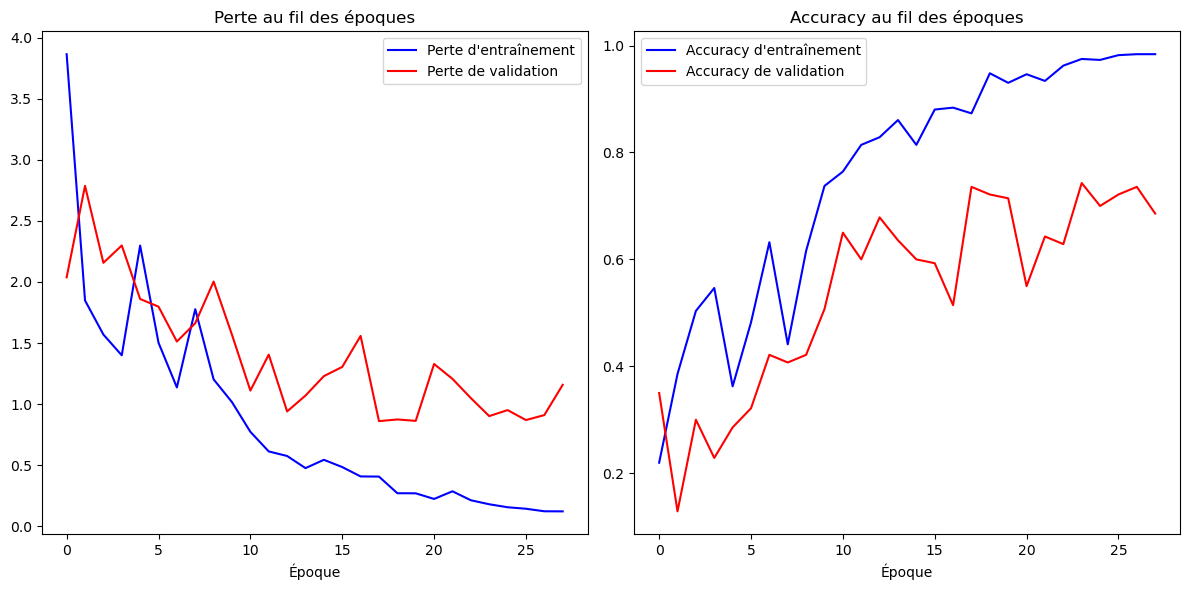

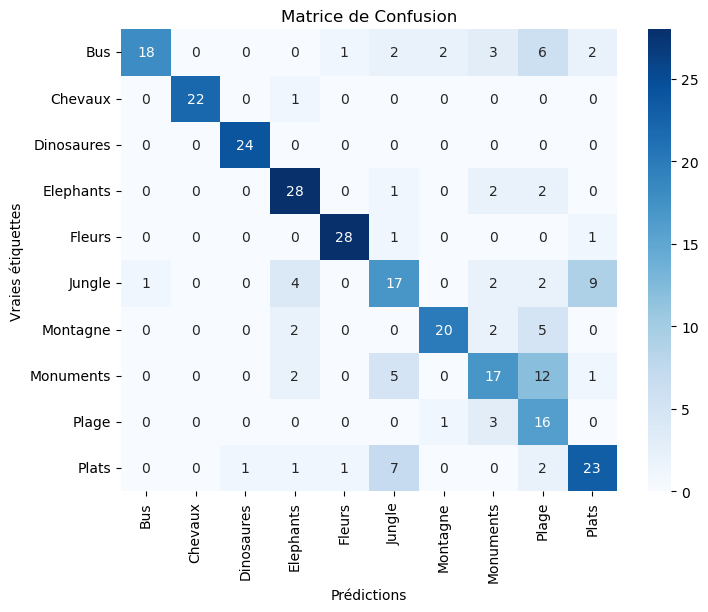

              precision    recall  f1-score   support

         Bus       0.95      0.53      0.68        34
     Chevaux       1.00      0.96      0.98        23
  Dinosaures       0.96      1.00      0.98        24
   Elephants       0.74      0.85      0.79        33
      Fleurs       0.93      0.93      0.93        30
      Jungle       0.52      0.49      0.50        35
    Montagne       0.87      0.69      0.77        29
   Monuments       0.59      0.46      0.52        37
       Plage       0.36      0.80      0.49        20
       Plats       0.64      0.66      0.65        35

    accuracy                           0.71       300
   macro avg       0.75      0.74      0.73       300
weighted avg       0.75      0.71      0.72       300



In [59]:
y_predict = model.predict(X_test)
plot_training_history(history)
plot_confusion_matrix(y_test, np.argmax(y_predict, axis=1))
print(classification_report(label_encoder.inverse_transform(y_test), label_encoder.inverse_transform(np.argmax(y_predict, axis=1))))

## Complexification du modèle

In [14]:
# Créer un modèle CNN amélioré avec une complexité accrue (model3)
model3 = Sequential()

# Couche de convolution 1
model3.add(Conv2D(32, (3, 3), input_shape=(256, 256, 3), activation='relu'))
model3.add(MaxPooling2D(pool_size=(2, 2)))

# Couche de convolution 2
model3.add(Conv2D(64, (3, 3), activation='relu'))
model3.add(MaxPooling2D(pool_size=(2, 2)))

# Aplatir les données
model3.add(Flatten())

# Couche Dense 1
model3.add(Dense(32, activation='relu'))
model3.add(Dropout(0.2))

# Couche Dense 2
model3.add(Dense(64, activation='relu'))
model3.add(Dropout(0.3))

# Couche Dense 3
model3.add(Dense(128, activation='relu'))
model3.add(Dropout(0.3))

# Couche de sortie avec le nombre de classes et une activation softmax
model3.add(Dense(10, activation='softmax'))

# Compiler le modèle en utilisant l'optimiseur Adam
model3.compile(loss='sparse_categorical_crossentropy', optimizer=Adam(learning_rate=0.001), metrics=['accuracy'])




In [15]:
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Entraîner le modèle en utilisant l'arrêt anticipé
history = model3.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.2, callbacks=[early_stopping])

Epoch 1/50
18/18 [==============================] - 26s 1s/step - loss: 2.8104 - accuracy: 0.1536 - val_loss: 2.2104 - val_accuracy: 0.2571
Epoch 2/50
18/18 [==============================] - 22s 1s/step - loss: 2.1257 - accuracy: 0.2429 - val_loss: 1.9609 - val_accuracy: 0.3000
Epoch 3/50
18/18 [==============================] - 21s 1s/step - loss: 1.9256 - accuracy: 0.3143 - val_loss: 1.7929 - val_accuracy: 0.3429
Epoch 4/50
18/18 [==============================] - 21s 1s/step - loss: 1.7282 - accuracy: 0.3643 - val_loss: 1.6164 - val_accuracy: 0.3929
Epoch 5/50
18/18 [==============================] - 21s 1s/step - loss: 1.7272 - accuracy: 0.3750 - val_loss: 1.7012 - val_accuracy: 0.4071
Epoch 6/50
18/18 [==============================] - 21s 1s/step - loss: 1.5434 - accuracy: 0.4304 - val_loss: 1.4723 - val_accuracy: 0.4286
Epoch 7/50
18/18 [==============================] - 21s 1s/step - loss: 1.5084 - accuracy: 0.4196 - val_loss: 1.3403 - val_accuracy: 0.4643
Epoch 8/50
18/18 [==

10/10 [==============================] - 3s 278ms/step


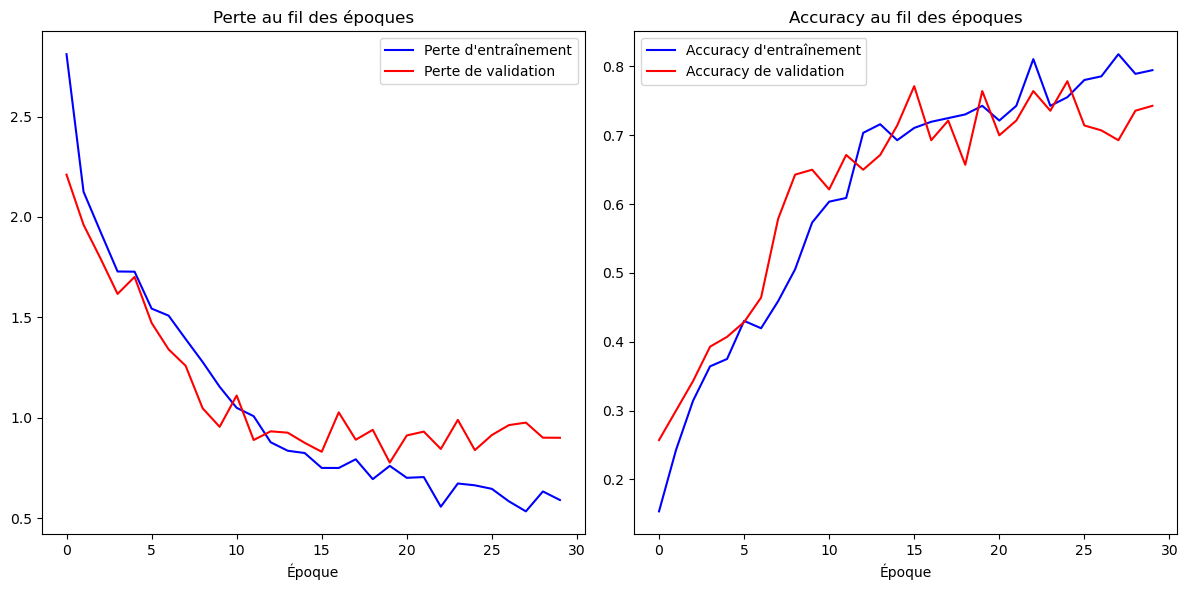

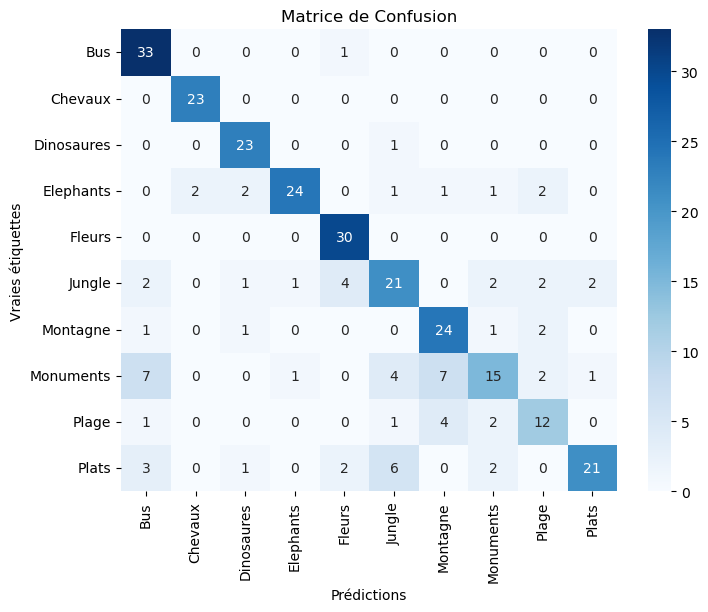

              precision    recall  f1-score   support

         Bus       0.70      0.97      0.81        34
     Chevaux       0.92      1.00      0.96        23
  Dinosaures       0.82      0.96      0.88        24
   Elephants       0.92      0.73      0.81        33
      Fleurs       0.81      1.00      0.90        30
      Jungle       0.62      0.60      0.61        35
    Montagne       0.67      0.83      0.74        29
   Monuments       0.65      0.41      0.50        37
       Plage       0.60      0.60      0.60        20
       Plats       0.88      0.60      0.71        35

    accuracy                           0.75       300
   macro avg       0.76      0.77      0.75       300
weighted avg       0.76      0.75      0.74       300

0.743


In [16]:
model3.evaluate(X_test, y_test)
y_predict = model3.predict(X_test)
plot_training_history(history)
plot_confusion_matrix(y_test, np.argmax(y_predict, axis=1))
print(classification_report(label_encoder.inverse_transform(y_test), label_encoder.inverse_transform(np.argmax(y_predict, axis=1))))
print(round(f1_score(y_test, np.argmax(y_predict, axis=1), average='weighted'),3))

# Ajout de data augmentation pour faire monter la précision

In [4]:

# Créer un modèle CNN amélioré avec data augmentation (model4)
model4 = Sequential()

# Utiliser un générateur de données pour la data augmentation
datagen = ImageDataGenerator(
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)



# Couche de convolution 1
model4.add(Conv2D(32, (3, 3), input_shape=(256, 256, 3), activation='relu'))
model4.add(MaxPooling2D(pool_size=(2, 2)))

# Couche de convolution 2
model4.add(Conv2D(64, (3, 3), activation='relu'))
model4.add(MaxPooling2D(pool_size=(2, 2)))

# Couche de convolution 3
model4.add(Conv2D(128, (3, 3), activation='relu'))
model4.add(MaxPooling2D(pool_size=(2, 2)))

# Aplatir les données
model4.add(Flatten())

# Couche Dense 1
model4.add(Dense(256, activation='relu'))
model4.add(Dropout(0.3))

# Couche Dense 2
model4.add(Dense(128, activation='relu'))
model4.add(Dropout(0.3))

# Couche de sortie avec le nombre de classes et une activation softmax
model4.add(Dense(10, activation='softmax'))

# Compiler le modèle en utilisant l'optimiseur Adam
model4.compile(loss='sparse_categorical_crossentropy', optimizer=Adam(learning_rate=0.001), metrics=['accuracy'])

#early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Entraîner le modèle en utilisant l'arrêt anticipé et la data augmentation
#history = model4.fit(datagen.flow(X_train, y_train, batch_size=32), epochs=50, validation_data=(X_test, y_test), callbacks=[early_stopping])
history = model4.fit(datagen.flow(X_train, y_train, batch_size=32), epochs=50, validation_data=(X_test, y_test))


Epoch 1/50
22/22 [==============================] - 57s 2s/step - loss: 2.1351 - accuracy: 0.2886 - val_loss: 1.4591 - val_accuracy: 0.5067
Epoch 2/50
22/22 [==============================] - 71s 3s/step - loss: 1.6061 - accuracy: 0.4057 - val_loss: 1.3866 - val_accuracy: 0.4600
Epoch 3/50
22/22 [==============================] - 56s 3s/step - loss: 1.3559 - accuracy: 0.4943 - val_loss: 1.1440 - val_accuracy: 0.5633
Epoch 4/50
22/22 [==============================] - 73s 3s/step - loss: 1.2483 - accuracy: 0.5600 - val_loss: 1.0620 - val_accuracy: 0.5933
Epoch 5/50
22/22 [==============================] - 73s 3s/step - loss: 1.1001 - accuracy: 0.6129 - val_loss: 0.8369 - val_accuracy: 0.7000
Epoch 6/50
22/22 [==============================] - 62s 3s/step - loss: 1.1048 - accuracy: 0.6129 - val_loss: 0.9087 - val_accuracy: 0.6900
Epoch 7/50
22/22 [==============================] - 61s 3s/step - loss: 0.9885 - accuracy: 0.6357 - val_loss: 0.8334 - val_accuracy: 0.7300
Epoch 8/50
22/22 [==

In [5]:
model4.evaluate(X_test, y_test)

10/10 [==============================] - 6s 536ms/step - loss: 0.6429 - accuracy: 0.8367


[0.6428574919700623, 0.8366666436195374]

# Evaluation du modèle

10/10 [==============================] - 5s 435ms/step


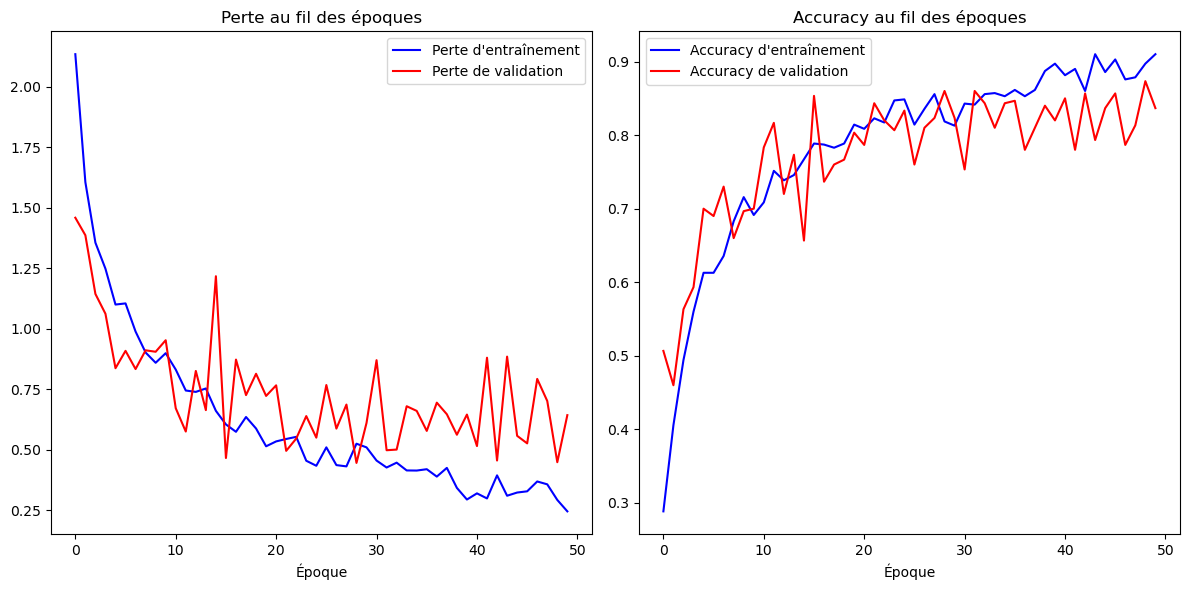

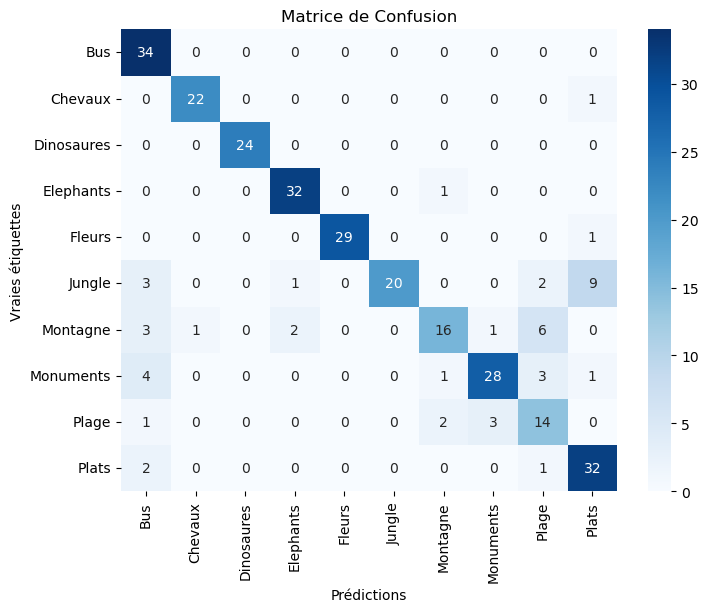

              precision    recall  f1-score   support

         Bus       0.72      1.00      0.84        34
     Chevaux       0.96      0.96      0.96        23
  Dinosaures       1.00      1.00      1.00        24
   Elephants       0.91      0.97      0.94        33
      Fleurs       1.00      0.97      0.98        30
      Jungle       1.00      0.57      0.73        35
    Montagne       0.80      0.55      0.65        29
   Monuments       0.88      0.76      0.81        37
       Plage       0.54      0.70      0.61        20
       Plats       0.73      0.91      0.81        35

    accuracy                           0.84       300
   macro avg       0.85      0.84      0.83       300
weighted avg       0.86      0.84      0.83       300

0.833


In [7]:
model4.evaluate(X_test, y_test)
y_predict = model4.predict(X_test)
plot_training_history(history)
plot_confusion_matrix(y_test, np.argmax(y_predict, axis=1))
print(classification_report(label_encoder.inverse_transform(y_test), label_encoder.inverse_transform(np.argmax(y_predict, axis=1))))
print(round(f1_score(y_test, np.argmax(y_predict, axis=1), average='weighted'),3))